<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Modelos </p>Conceptos </p> Clasificación     </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado 2026-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1. Contexto </FONT>

Una institución de salud desea desarrollar un modelo de aprendizaje automático que permita identificar, a partir de la información disponible durante la valoración inicial de un paciente, si existe necesidad de hospitalización.

Para ello, se dispone de información demográfica y clínica relacionada con la edad, sexo, índice de masa corporal, signos vitales, niveles de glucosa, presencia de comorbilidades y tiempo de evolución de los síntomas.

El objetivo es construir un modelo de clasificación binaria capaz de predecir la variable hospitalizacion, donde 0 representa que el paciente no requiere hospitalización y 1 que requiere hospitalización.

| Variable                | Tipo                              | Descripción                                                                                      |
| ----------------------- | --------------------------------- | ------------------------------------------------------------------------------------------------ |
| **edad**                | Numérica discreta                 | Edad del paciente expresada en años. En los datos toma valores entre 18 y 90 años.               |
| **sexo**                | Categórica binaria                | Sexo del paciente codificado numéricamente como 0 y 1.                                           |
| **imc**                 | Numérica continua                 | Índice de masa corporal (IMC) del paciente, expresado en kg/m².                                  |
| **presion_sistolica**   | Numérica continua                 | Presión arterial sistólica del paciente, expresada en mmHg.                                      |
| **frecuencia_cardiaca** | Numérica continua                 | Número de latidos del corazón por minuto (lpm).                                                  |
| **saturacion_oxigeno**  | Numérica continua                 | Porcentaje de saturación de oxígeno en sangre (SpO₂).                                            |
| **temperatura**         | Numérica continua                 | Temperatura corporal del paciente, expresada en grados Celsius (°C).                             |
| **glucosa**             | Numérica continua                 | Nivel de glucosa en sangre del paciente, expresado en mg/dL.                                     |
| **comorbilidades**      | Numérica discreta                 | Número de condiciones médicas adicionales o enfermedades preexistentes que presenta el paciente. |
| **dias_sintomas**       | Numérica discreta                 | Número de días transcurridos desde el inicio de los síntomas hasta la valoración.                |
| **hospitalizacion**     | **Categórica binaria (objetivo)** | Variable que se desea predecir: **0 = no hospitalización; 1 = hospitalización**.                 |

**link de los datos:**

https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_hospitalizacion_3000.csv



# <FONT SIZE=5 COLOR="purple"> 2 Librerías y carga de los datos </FONT>

In [2]:
# Manipulación de data.frames
import pandas as pd
import numpy  as np

# Librerías para Gráficos
import matplotlib.pyplot    as plt
import seaborn              as sns
import plotly.express       as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de machine learning


from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.naive_bayes        import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier


# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# para hacer la curva ROC
from sklearn.metrics            import roc_auc_score
from sklearn.metrics            import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV
# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

**Función de evaluación de modelo de clasificación binaria**

In [3]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",graficar = True):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en test
    sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':20},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Test-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df


In [4]:
# cargar los datos
hospital = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_hospitalizacion_3000.csv")
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


# <FONT SIZE=5 COLOR="purple"> 3 Exploración rápida de los datos </FONT>

In [5]:
# cabeza de los datos
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


In [6]:
# cola de los datos
hospital.tail()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
2995,40,1,34.28,89.67,83.22,95.99,35.72,143.09,2,2,0
2996,38,1,22.54,140.16,79.36,92.26,37.80,124.35,2,4,1
2997,70,0,27.69,131.90,85.73,96.41,36.74,120.67,2,5,1
2998,71,1,32.29,135.56,77.50,95.14,37.06,92.11,2,3,0
2999,85,1,27.31,132.90,81.15,93.42,37.62,85.15,3,3,1


In [7]:
# tamaño de los datos
hospital.shape

(3000, 11)

In [8]:
# nombre de las columnas
hospital.columns

Index(['edad', 'sexo', 'imc', 'presion_sistolica', 'frecuencia_cardiaca',
       'saturacion_oxigeno', 'temperatura', 'glucosa', 'comorbilidades',
       'dias_sintomas', 'hospitalizacion'],
      dtype='object')

In [9]:
# información de los datos
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 3000 non-null   int64  
 1   sexo                 3000 non-null   int64  
 2   imc                  3000 non-null   float64
 3   presion_sistolica    3000 non-null   float64
 4   frecuencia_cardiaca  3000 non-null   float64
 5   saturacion_oxigeno   3000 non-null   float64
 6   temperatura          3000 non-null   float64
 7   glucosa              3000 non-null   float64
 8   comorbilidades       3000 non-null   int64  
 9   dias_sintomas        3000 non-null   int64  
 10  hospitalizacion      3000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 257.9 KB


Observe que todas las variables son numéricas y están completas

In [10]:
# estadísticas descriptivas
hospital.describe()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,52.238667,0.499000,27.402813,128.157157,77.441057,96.137383,36.797183,108.558917,1.328667,4.049667,0.502000
std,17.087726,0.500082,4.760697,18.024098,12.856219,1.907426,0.652278,26.973533,1.157479,2.030084,0.500079
min,18.000000,0.000000,16.000000,85.000000,45.000000,89.640000,35.000000,55.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,24.170000,115.767500,68.867500,94.840000,36.360000,89.867500,0.000000,3.000000,0.000000
50%,52.000000,0.000000,27.550000,127.910000,77.470000,96.150000,36.790000,108.765000,1.000000,4.000000,1.000000
75%,64.000000,1.000000,30.622500,140.152500,86.272500,97.390000,37.240000,126.522500,2.000000,5.000000,1.000000
max,90.000000,1.000000,44.030000,191.890000,123.730000,100.000000,38.990000,211.360000,6.000000,13.000000,1.000000


Vamos a realizar lo siguiente como complemento

- análisis de la variable `edad`

- diagrama de correlaciones

- análisis de la variable `hospitalización`

Lo demás se deja al lector

In [11]:
# estadística de edad
hospital.edad.describe()

,edad
count,3000.000000
mean,52.238667
std,17.087726
min,18.000000
25%,40.000000
50%,52.000000
75%,64.000000
max,90.000000


La edad varia desde los 18 años a los 90 años, con un promedio de 52 años

In [12]:
# histograma para ver la distribución
px.histogram(hospital.edad,
             nbins = 30)

tiene un comportamiento más o menos simétrico

In [13]:
# boxplot de la variable edad
px.box(hospital,
       x = "hospitalizacion",
       y = "edad",
       color = "hospitalizacion")

- Las personas hospitalizadas son un poco mayores comparadas con las que no fueron hospitalizadas.

- No hay valores atípicos

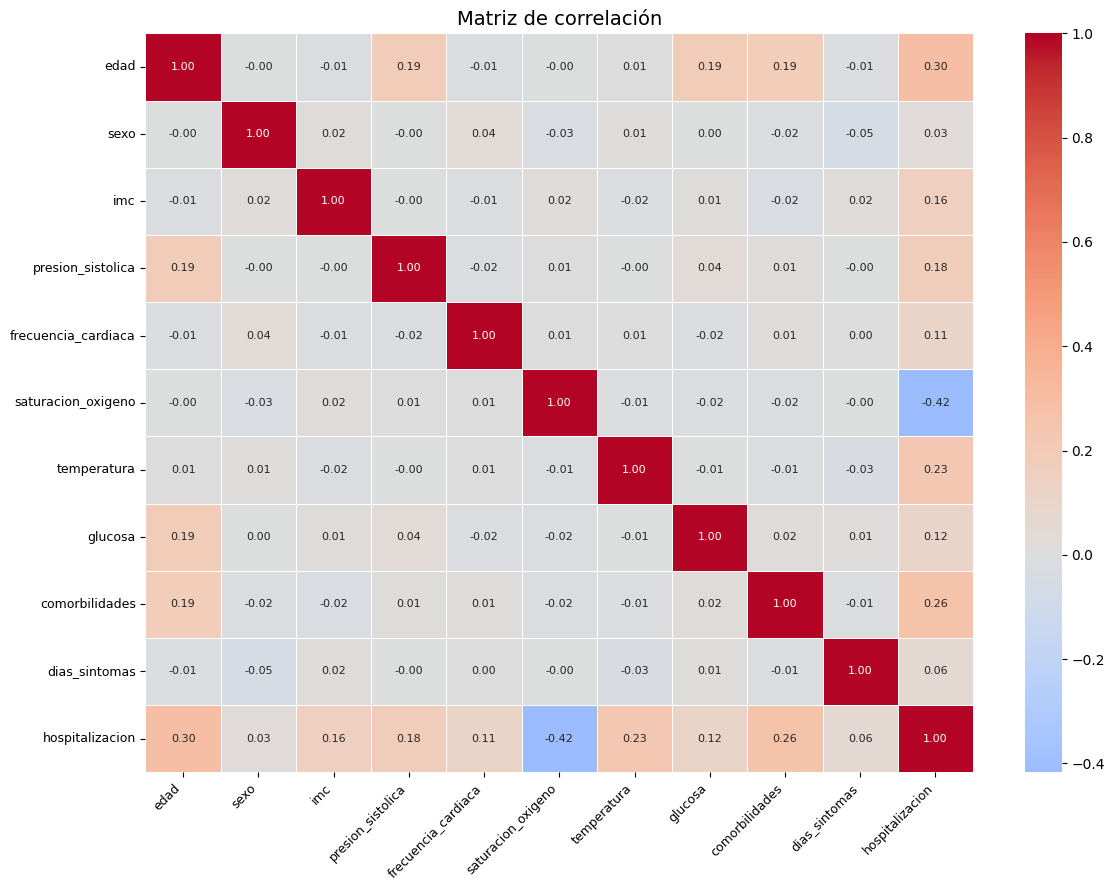

In [14]:
# diagrama de correlación
plt.figure(figsize=(12, 9))

# Mapa de correlación
sns.heatmap(hospital.corr(),              # matriz de correlaciones
            annot=True,                   # para colocar números adentro (correlaciones)
            fmt=".2f",                    # formato de los números
            cmap="coolwarm",              # colores frio-caliente
            center=0,                     # centro de la escala
            annot_kws={"size": 8},        # tamaño de los números
            linewidths=0.5
)

# Tamaño de etiquetas
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)

plt.title("Matriz de correlación", fontsize=14)

plt.tight_layout()
plt.show()

observe que no hay variables con correlaciones fuertes

In [15]:
# tabla de frecuencias de la variable hospitalización
hospital.hospitalizacion.value_counts()

,count
hospitalizacion,
1,1506
0,1494


los datos están distribuidos de manera equilibrada

# <FONT SIZE=5 COLOR="purple"> 4 Modelos </FONT>

Para este ejemplo usaremos varios modelos.

$$P(Hospitalizacion = 1 \mid X)$$
y
$$P(Hospitalizacion = 0 \mid X)$$



In [16]:
# 1 Dividir en dos conjuntos
# las variables predictoras
X = hospital.drop("hospitalizacion", axis=1)
# la variable objetivo
y = hospital["hospitalizacion"]

# 2. conjunto de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba


In [17]:
# definimos el modelo de KNN
modelo_knn = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('modelo_knn', KNeighborsClassifier())
      ])
# entrenamos el modelo
modelo_knn.fit(X_train,y_train)

# modelo de regresión logística
modelo_log = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('modelo_log', LogisticRegression())
      ])
# entrenamos el modelo
modelo_log.fit(X_train,y_train)

# definimos el modelo de árboles de decisión /
modelo_tree =  DecisionTreeClassifier(max_depth= 5, random_state=42)
# entrenamos el modelo
modelo_tree.fit(X_train,y_train)

# definimos el modelo de support vector machine
modelo_svc = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('modelo_log', SVC())
      ])
# entrenamos el modelo
modelo_svc.fit(X_train,y_train)

# definimos el modelo de Naive Bayes
modelo_naive = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('modelo_nb', GaussianNB())
      ])
# entrenamos el modelo
modelo_naive.fit(X_train,y_train)

# definimos el modelo de Random Forest
modelo_rf = RandomForestClassifier(max_depth=5,random_state=42)
# entrenamos el modelo
modelo_rf.fit(X_train, y_train)

# definimos el modelo de XGBoost
modelo_xgb = XGBClassifier(max_depth=5, random_state=42)
# entrenamos el modelo
modelo_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# <FONT SIZE=5 COLOR="purple"> 5. Evaluación de los modelos </FONT>

In [18]:
# solo las métricas
df_knn = evaluacion_modelo(modelo_knn, X_train, y_train, X_test, y_test, nombre_modelo= "KNN", graficar = False)
df_log = evaluacion_modelo(modelo_log, X_train, y_train, X_test, y_test, nombre_modelo= "Regresión Logística", graficar = False)
df_tree = evaluacion_modelo(modelo_tree, X_train, y_train, X_test, y_test, nombre_modelo= "Árboles de Decisión", graficar = False)
df_svc = evaluacion_modelo(modelo_svc, X_train, y_train, X_test, y_test, nombre_modelo= "SVC", graficar = False)
df_naive = evaluacion_modelo(modelo_naive, X_train, y_train, X_test, y_test, nombre_modelo= "Naive-Bayes", graficar = False)
df_rf = evaluacion_modelo(modelo_rf, X_train, y_train, X_test, y_test, nombre_modelo= "Random Forest", graficar = False)
df_xgb = evaluacion_modelo(modelo_xgb, X_train, y_train, X_test, y_test, nombre_modelo= "XGBoost", graficar = False)

In [19]:
# pegar todas las métricas
resultados = pd.concat([df_knn,
                        df_log,
                        df_tree,
                        df_svc,
                        df_naive,
                        df_rf,
                        df_xgb], axis=1 )

resultados


,KNN_train,KNN_test,Regresión Logística_train,Regresión Logística_test,Árboles de Decisión_train,Árboles de Decisión_test,SVC_train,SVC_test,Naive-Bayes_train,Naive-Bayes_test,Random Forest_train,Random Forest_test,XGBoost_train,XGBoost_test
accuracy,0.856190,0.813333,0.891905,0.892222,0.808095,0.741111,0.902381,0.878889,0.858095,0.850000,0.874762,0.808889,0.997619,0.821111
recall,0.860531,0.809735,0.889943,0.869469,0.836812,0.763274,0.907021,0.869469,0.839658,0.820796,0.878558,0.809735,0.998102,0.825221
specificity,0.851816,0.816964,0.893881,0.915179,0.779159,0.718750,0.897706,0.888393,0.876673,0.879464,0.870937,0.808036,0.997132,0.816964
precision,0.854049,0.816964,0.894185,0.911833,0.792453,0.732484,0.899341,0.887133,0.872781,0.872941,0.872762,0.809735,0.997156,0.819780
f1,0.857278,0.813333,0.892059,0.890147,0.814029,0.747562,0.903165,0.878212,0.855899,0.846066,0.875650,0.809735,0.997629,0.822492


- Un buen modelo no debe evaluarse únicamente por su desempeño sobre los datos de entrenamiento.

- XGBoost alcanza aproximadamente $99.8 \%$ de accuracy en entrenamiento, pero disminuye a 82.1 % en prueba, lo que evidencia sobreajuste.

- La regresión logística presenta aproximadamente 89.2 % tanto en entrenamiento como en prueba, mostrando una mejor capacidad de generalización en esta partición de los datos.

# <FONT SIZE=5 COLOR="purple"> 6. Curvas ROC y AUC </FONT>

Ahora hacemos la curva ROC

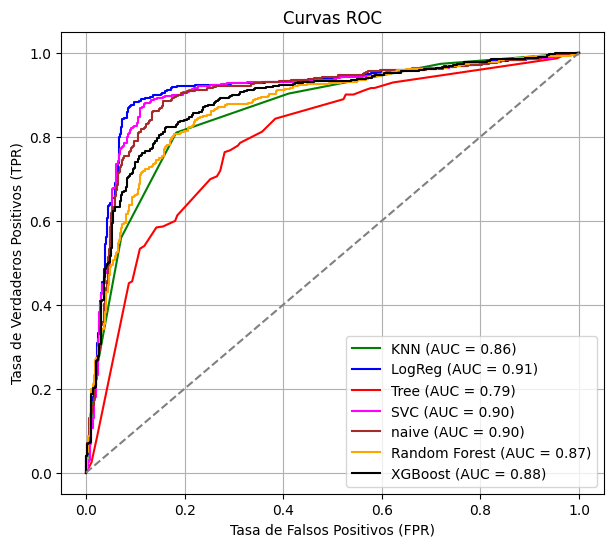

In [20]:
# veamos la curva ROC
fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test)[:,1])
fpr_test_log, tpr_test_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test)[:,1])
fpr_test_tree, tpr_test_tree, _ = roc_curve(y_test, modelo_tree.predict_proba(X_test)[:,1])
fpr_test_svc, tpr_test_svc, _ = roc_curve(y_test, modelo_svc.decision_function(X_test))
fpr_test_naive, tpr_test_naive, _ = roc_curve(y_test, modelo_naive.predict_proba(X_test)[:,1])
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, modelo_rf.predict_proba(X_test)[:,1])
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test, modelo_xgb.predict_proba(X_test)[:,1])


# AUC
auc_test_knn = roc_auc_score(y_test, modelo_knn.predict_proba(X_test)[:,1])
auc_test_log = roc_auc_score(y_test, modelo_log.predict_proba(X_test)[:,1])
auc_test_tree = roc_auc_score(y_test, modelo_tree.predict_proba(X_test)[:,1])
auc_test_svc = roc_auc_score(y_test, modelo_svc.decision_function(X_test))
auc_test_naive = roc_auc_score(y_test, modelo_naive.predict_proba(X_test)[:,1])
auc_test_rf = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:,1])
auc_test_xgb = roc_auc_score(y_test, modelo_xgb.predict_proba(X_test)[:,1])


# Gráfica curva ROC
plt.figure(figsize=(7,6))
plt.plot(fpr_test_knn, tpr_test_knn, color='green', label=f'KNN (AUC = {auc_test_knn:.2f})')
plt.plot(fpr_test_log, tpr_test_log, color='blue', label=f'LogReg (AUC = {auc_test_log:.2f})')
plt.plot(fpr_test_tree, tpr_test_tree, color='red', label=f'Tree (AUC = {auc_test_tree:.2f})')
plt.plot(fpr_test_svc, tpr_test_svc, color='magenta', label=f'SVC (AUC = {auc_test_svc:.2f})')
plt.plot(fpr_test_naive, tpr_test_naive, color='brown', label=f'naive (AUC = {auc_test_naive:.2f})')
plt.plot(fpr_test_rf, tpr_test_rf, color='orange', label=f'Random Forest (AUC = {auc_test_rf:.2f})')
plt.plot(fpr_test_xgb, tpr_test_xgb, color='black', label=f'XGBoost (AUC = {auc_test_xgb:.2f})')

# Línea diagonal (azar)
plt.plot([0,1], [0,1], color='gray', linestyle='--')

# Detalles del gráfico
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Observamos que el mejor modelo es el de regresión logística

# <FONT SIZE=5 COLOR="purple"> 7. Optimización de Hiperparámetros </FONT>

Ahora, con ese modelo podemos optimizar hiperparámetros, para ver si se mejora un poco.

In [21]:
# optimización de hiperparámetros
# Crear pipeline con escalador y modelo
pipe = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('classifier', LogisticRegression())
      ])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"classifier__penalty": ["l1", "l2"],
               "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
               "classifier__solver": ["liblinear", "lbfgs", "saga"],
               "classifier__max_iter": [100, 500, 1000]}

# hacemos la búsqueda en grilla con 5-folds
Grid = GridSearchCV(pipe,                        # el modelo aplicado
                    grid_params,                 # los parámetros que van a variar
                    cv = 10,                     # el número de folds
                    verbose = 1,
                    scoring = "accuracy")                 # para que imprima resultados. Posibilidades: 1,2 o 3
# Entrenar el modelo obtenido arriba
g_res = Grid.fit(X_train,y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


Vamos a revisar la búsqueda en grilla para buscar el mejor modelo con la métrica **recall**

In [22]:
# optimización de hiperparámetros
# Crear pipeline con escalador y modelo
pipe = Pipeline(steps=[
      ('escalar', StandardScaler()),
      ('classifier', LogisticRegression())
      ])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"classifier__penalty": ["l1", "l2"],
               "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
               "classifier__solver": ["liblinear", "lbfgs", "saga"],
               "classifier__max_iter": [100, 500, 1000]}

# hacemos la búsqueda en grilla con 5-folds
Grid = GridSearchCV(pipe,                        # el modelo aplicado
                    grid_params,                 # los parámetros que van a variar
                    cv = 10,                     # el número de folds
                    verbose = 1,                 # para que imprima resultados. Posibilidades: 1,2 o 3
                    scoring = "recall")
# Entrenar el modelo obtenido arriba
g_res2 = Grid.fit(X_train,y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


In [23]:
# revisamos el mejor modelo con validación cruzada.
print("mejores hiperparámetros", g_res.best_params_ )
print("mejor score: accucary", g_res.best_score_)
print("mejor modelo", g_res.best_estimator_ )

mejores hiperparámetros {'classifier__C': 0.1, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
mejor score: accucary 0.8885714285714286
mejor modelo Pipeline(steps=[('escalar', StandardScaler()),
                ('classifier', LogisticRegression(C=0.1, solver='liblinear'))])


In [24]:
# revisamos el mejor modelo con validación cruzada.
print("mejores hiperparámetros", g_res2.best_params_ )
print("mejor score: recall", g_res2.best_score_)
print("mejor modelo", g_res2.best_estimator_ )

mejores hiperparámetros {'classifier__C': 10, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
mejor score: recall 0.8851482479784367
mejor modelo Pipeline(steps=[('escalar', StandardScaler()),
                ('classifier', LogisticRegression(C=10, solver='liblinear'))])


Hagamos validación cruzada con el mejor modelo de *recall*

In [25]:
from sklearn.model_selection import cross_val_score

# Creamos el modelo
modelo_cv = Pipeline(steps=[
    ('escalar', StandardScaler()),
    ('modelo_log_best2', g_res2.best_estimator_)])

# Validación cruzada con 10 folds
resultados_cv = cross_val_score(modelo_cv,
                                X_train,
                                y_train,
                                cv=10,
                                scoring='accuracy')

# Resultados
print("Accuracy de cada fold:")
print(resultados_cv)

print("\nAccuracy promedio:")
print(resultados_cv.mean())

print("\nDesviación estándar:")
print(resultados_cv.std())

Accuracy de cada fold:
[0.8952381  0.9047619  0.9        0.89047619 0.88095238 0.8952381
 0.84761905 0.91904762 0.8952381  0.85714286]

Accuracy promedio:
0.8885714285714286

Desviación estándar:
0.020448486241508475


# <FONT SIZE=5 COLOR="purple"> 8. Guardar el mejor Modelo </FONT>

Guardamos ese modelo

In [26]:
# guardar el modelo
import joblib

# Obtener el mejor modelo
model_best_log2 = g_res2.best_estimator_

# Guardar
joblib.dump(model_best_log2, "model_best_log2.pkl")

['model_best_log2.pkl']

In [ ]:
# para cargarlo
# model_best_log = joblib.load("model_best_log.pkl")

In [27]:
model_best_log2 = g_res2.best_estimator_

# <FONT SIZE=5 COLOR="purple"> 9. Hacer predicciones </FONT>

Ahora vamos a hacer algunas predicciones

In [28]:
# cargar datos para predecir
hospital_pred = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/hospitalizacion_50_nuevos_pacientes.csv")
hospital_pred.head()

,id_paciente,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas
0,1,58,1,32.80,123.53,46.07,97.96,35.19,135.17,3,7
1,2,29,0,36.88,111.79,91.91,98.75,38.06,76.67,0,6
2,3,56,1,26.58,113.07,77.63,95.36,36.78,113.53,3,5
3,4,70,1,30.84,121.18,60.17,95.96,36.70,119.14,1,2
4,5,42,1,36.19,126.47,67.93,94.36,36.92,56.58,2,3


In [29]:
# eliminamos la primera variable
hospital_pred.drop("id_paciente", axis=1, inplace=True)

In [30]:
hospital_pred.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas
0,58,1,32.80,123.53,46.07,97.96,35.19,135.17,3,7
1,29,0,36.88,111.79,91.91,98.75,38.06,76.67,0,6
2,56,1,26.58,113.07,77.63,95.36,36.78,113.53,3,5
3,70,1,30.84,121.18,60.17,95.96,36.70,119.14,1,2
4,42,1,36.19,126.47,67.93,94.36,36.92,56.58,2,3


Hacemos las predicciones

In [31]:
predicciones = model_best_log2.predict(hospital_pred)
probabilidades = model_best_log2.predict_proba(hospital_pred)[:,1]
hospital_pred["predicciones"] = predicciones
hospital_pred["probabilidades"] = probabilidades
hospital_pred.head(10)


,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,predicciones,probabilidades
0,58,1,32.80,123.53,46.07,97.96,35.19,135.17,3,7,0,0.125067
1,29,0,36.88,111.79,91.91,98.75,38.06,76.67,0,6,0,0.229143
2,56,1,26.58,113.07,77.63,95.36,36.78,113.53,3,5,1,0.848014
3,70,1,30.84,121.18,60.17,95.96,36.70,119.14,1,2,1,0.526838
4,42,1,36.19,126.47,67.93,94.36,36.92,56.58,2,3,1,0.873663
5,32,0,24.05,141.06,86.01,96.61,36.51,125.43,0,3,0,0.077918
6,44,0,26.41,132.11,91.46,95.06,36.13,98.49,4,7,1,0.915246
7,71,1,27.58,138.08,70.74,90.39,36.11,134.96,2,8,1,0.997304
8,37,1,23.55,141.38,99.70,97.51,36.59,134.94,1,6,0,0.228822
9,53,1,34.31,132.02,73.88,95.31,36.69,135.47,1,7,1,0.862953


Podemos definir unos rangos de manera didáctica no tiene justificación clínica. esta se la da el usuario que está haciendo el modelo

In [32]:
hospital_pred["riesgo"] = pd.cut(
    hospital_pred["probabilidades"],
    bins=[0, 0.3, 0.5, 0.7, 1],
    labels=["Bajo", "Moderado", "Alto", "Muy alto"],
    include_lowest=True
)

hospital_pred[
    ["predicciones", "probabilidades", "riesgo"]
].head(15)

,predicciones,probabilidades,riesgo
0,0,0.125067,Bajo
1,0,0.229143,Bajo
2,1,0.848014,Muy alto
3,1,0.526838,Alto
4,1,0.873663,Muy alto
5,0,0.077918,Bajo
6,1,0.915246,Muy alto
7,1,0.997304,Muy alto
8,0,0.228822,Bajo
9,1,0.862953,Muy alto


# <FONT SIZE=5 COLOR="purple"> 10. Revisar los coeficientes (Regresión Logística) </FONT>

In [33]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10,
                     shuffle=True,
                     random_state=42)

# Selección de variables con RFECV
rfecv = RFECV(estimator=model_best_log2,
              step=1,
              cv=cv,
              scoring="accuracy",
              importance_getter="named_steps.classifier.coef_")

# Entrenar RFECV
rfecv.fit(X_train, y_train)

# Resultados
print("Número óptimo de variables:", rfecv.n_features_)

print("\nVariables seleccionadas:")
print(X_train.columns[rfecv.support_].tolist())

Número óptimo de variables: 9

Variables seleccionadas:
['edad', 'imc', 'presion_sistolica', 'frecuencia_cardiaca', 'saturacion_oxigeno', 'temperatura', 'glucosa', 'comorbilidades', 'dias_sintomas']


In [34]:
resultado_rfecv = pd.DataFrame({"Variable": X_train.columns,
                                 "Seleccionada": rfecv.support_,
                                 "Ranking": rfecv.ranking_})

resultado_rfecv = resultado_rfecv.sort_values(by=["Ranking", "Variable"])
resultado_rfecv

,Variable,Seleccionada,Ranking
8,comorbilidades,True,1
9,dias_sintomas,True,1
0,edad,True,1
4,frecuencia_cardiaca,True,1
7,glucosa,True,1
2,imc,True,1
3,presion_sistolica,True,1
5,saturacion_oxigeno,True,1
6,temperatura,True,1
1,sexo,False,2


In [36]:
# Extraer la regresión logística del Pipeline
modelo_log = model_best_log2.named_steps["classifier"]

# Extraer los coeficientes
coeficientes = modelo_log.coef_[0]

# Crear tabla de importancia
importancia_variables = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": coeficientes,
    "Importancia": np.abs(coeficientes)
})

# Ordenar de mayor a menor importancia
importancia_variables = importancia_variables.sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

# Crear ranking
importancia_variables["Ranking"] = (
    importancia_variables.index + 1
)

importancia_variables

,Variable,Coeficiente,Importancia,Ranking
0,saturacion_oxigeno,-1.536323,1.536323,1
1,temperatura,0.915019,0.915019,2
2,comorbilidades,0.881659,0.881659,3
3,edad,0.774995,0.774995,4
4,imc,0.600127,0.600127,5
5,presion_sistolica,0.544145,0.544145,6
6,frecuencia_cardiaca,0.403806,0.403806,7
7,dias_sintomas,0.260138,0.260138,8
8,glucosa,0.218700,0.218700,9
9,sexo,0.015823,0.015823,10


- La magnitud absoluta de los coeficientes estandarizados permite comparar el aporte relativo de las variables a la función de decisión de la regresión logística.

- Cuanto mayor sea la magnitud, mayor es su peso dentro del modelo.

- El signo indica la dirección de la asociación con la clase positiva.